In [1]:
import dgrec
import matplotlib.pyplot as plt
import pandas as pd
import ast
from itertools import chain
from collections import defaultdict

# Define a color map for amino acids (standard convention)
aa_colors = {
    # Polar (charged)
    'D': '#E60A0A',  # ASP: Bright Red
    'E': '#E60A0A',  # GLU: Bright Red
    # Hydrophobic
    'A': '#E6E600',  # ALA: Yellow (approximated from "Dark Grey" in table, but ALA is often yellow in other schemes)
    'I': '#00FF00',  # ILE: Green
    'L': '#00FF00',  # LEU: Green
    'V': '#00FF00',  # VAL: Green
    'F': '#E6E600',  # PHE: Yellow (approximated)
    'W': '#E6E600',  # TRP: Yellow (approximated)
    'M': '#E6E600',  # MET: Yellow
    # Polar (uncharged)
    'N': '#00D4FF',  # ASN: Cyan
    'Q': '#00D4FF',  # GLN: Cyan
    'S': '#FF8000',  # SER: Orange
    'T': '#FF8000',  # THR: Orange
    'Y': '#FF8000',  # TYR: Orange
    'C': '#FFFF00',  # CYS: Yellow
    'P': '#DC9682',  # PRO: Flesh
    'G': '#E6E6E6',  # GLY: Light Grey
    # Basic
    'R': '#0000FF',  # ARG: Blue
    'H': '#0000FF',  # HIS: Pale Blue (approximated)
    'K': '#0000FF',  # LYS: Blue
    # Others
    '*': '#BE8665',  # Others: Tan
}


I0000 00:00:1781098076.324142   61266 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})

In [3]:
big_df=pd.read_csv('../Summary_all.csv')       
prot='MAQVQLVESGGGSVQAGGSLRLSCAASGYTINTDAVAWFRQAPGKGDERVAVIYTGSGNTNYADSVKGRFTISQDNAKNTVYLQMNSLKPEDTALYYCASGYYGASGYDFNNWGQGTQVTVSS'
tr='GTACTACTGTGCGTCTGGATACTATGGTGCCTCTGGGTATGACTTCAACAACTGGGGCCAGGGGACCCAGGTCACCGT' 
Frame=1
prot_129='QVQLVESGGGSVQAGGSLRLSCAASGYTINTDAVAWFRQAPGKGDERVAVIYTGSGNTNYADSVKGRFTISQDNAKNTVYLQMNSLKPEDTALYYCASGYYGASGYDFNNWGQGTQVTVSSALVPR'

dg=big_df[big_df['TR']==tr]
vr_mutants=ast.literal_eval(list(dg['Mutants'])[0])
vr_mutants = list(chain.from_iterable([k] * int(v) for k, v in vr_mutants.items()))

prot_vr=[dgrec.lstm.nt_prot(vr[1:]) for vr in vr_mutants]

# Fig 7 (a)

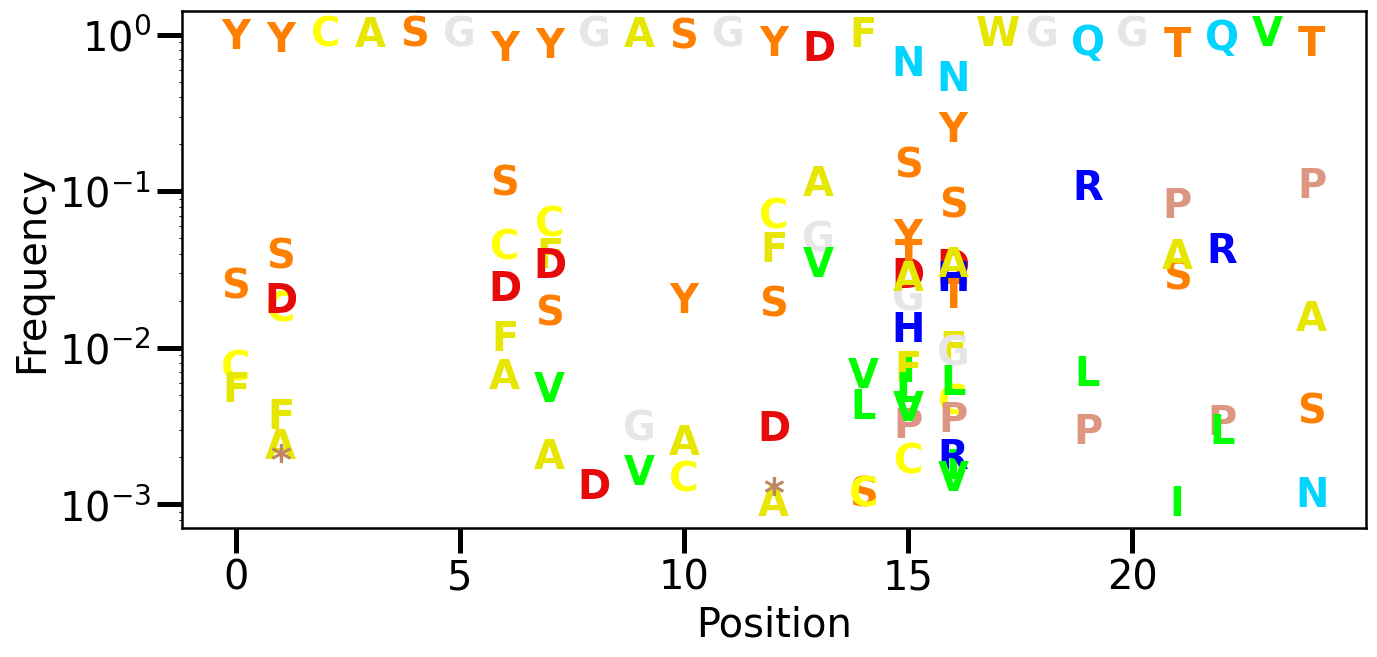

In [4]:
# Initialize a dictionary to hold frequency counts for each position
position_freqs = [defaultdict(int) for _ in range(len(prot_vr[0]))]

# Count frequencies for each position
for s in prot_vr:
    for i, char in enumerate(s):
        position_freqs[i][char] += 1

# Normalize frequencies
total_strings = len(prot_vr)
for i in range(len(position_freqs)):
    for char in position_freqs[i]:
        position_freqs[i][char] /= total_strings

# Create a single figure
plt.figure(figsize=(12, 6))

# For each position, plot letters with frequency > 1e-3
for pos in range(len(position_freqs)):
    freqs = position_freqs[pos]
    for char, freq in freqs.items():
        if freq > 1e-3:
            color = aa_colors.get(char, 'black')  # Default to black if not found
            plt.scatter(pos, freq, label=f'{char} at {pos}', alpha=0)
            plt.text(pos, freq, char, fontsize=24, ha='center', va='center', color=color, fontweight='bold')

# Customize the plot
plt.yscale('log')
plt.xlabel('Position',fontsize=24)
plt.ylabel('Frequency',fontsize=24)

#plt.grid(True, which="both", ls="--")
plt.xticks(list(range(0,len(position_freqs),5)),fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
#plt.savefig('TR_AA_freq_exp.svg')
plt.show()

# Fig 7 (b)

I0000 00:00:1781098102.266585   61266 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1197 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1781098106.397477   61408 cuda_dnn.cc:461] Loaded cuDNN version 92000


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


Generating sequence: 100%|██████████████████████| 78/78 [00:57<00:00,  1.35it/s]


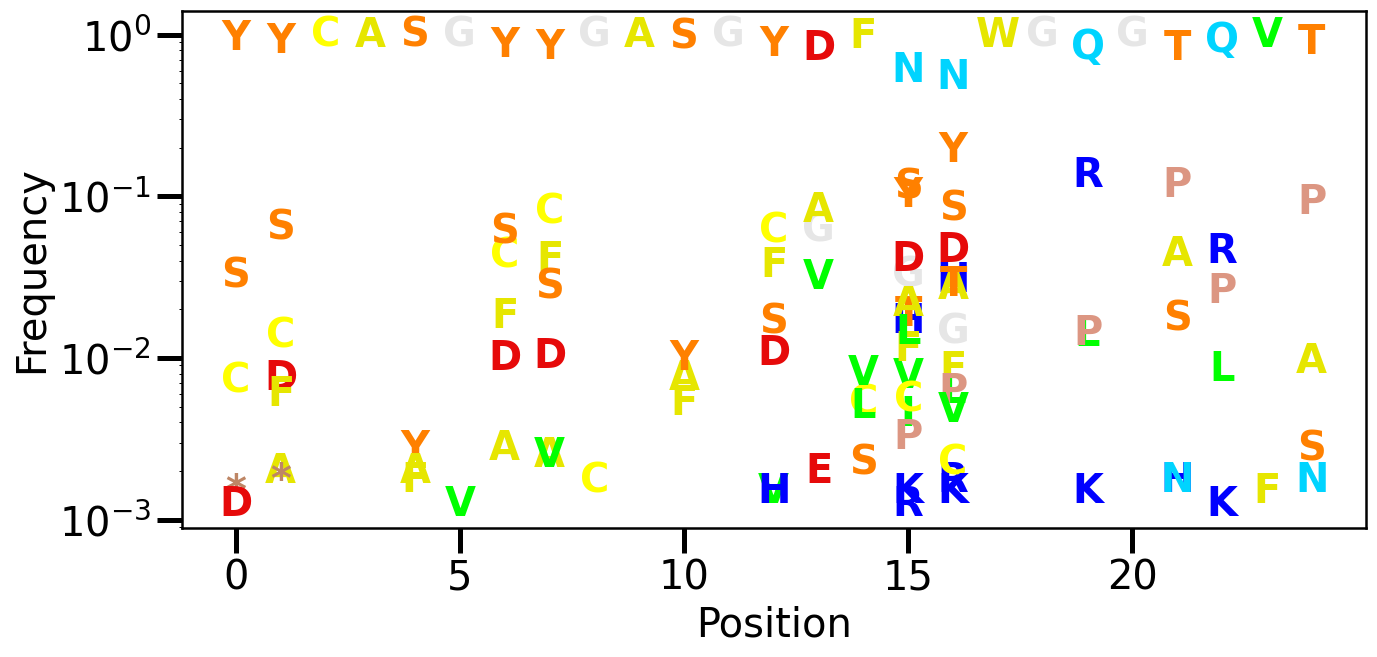

In [5]:
vrs=dgrec.lstm.generate_sequences_oneTR(tr, n=40000)
prot_vr=[dgrec.lstm.nt_prot(vr[1:]) for vr in vrs]

# Initialize a dictionary to hold frequency counts for each position
position_freqs = [defaultdict(int) for _ in range(len(prot_vr[0]))]

# Count frequencies for each position
for s in prot_vr:
    for i, char in enumerate(s):
        position_freqs[i][char] += 1

# Normalize frequencies
total_strings = len(prot_vr)
for i in range(len(position_freqs)):
    for char in position_freqs[i]:
        position_freqs[i][char] /= total_strings

# Create a single figure
plt.figure(figsize=(12, 6))

# For each position, plot letters with frequency > 1e-3
for pos in range(len(position_freqs)):
    freqs = position_freqs[pos]
    for char, freq in freqs.items():
        if freq > 1e-3:
            color = aa_colors.get(char, 'black')  # Default to black if not found
            plt.scatter(pos, freq, label=f'{char} at {pos}', alpha=0)
            plt.text(pos, freq, char, fontsize=24, ha='center', va='center', color=color, fontweight='bold')

# Customize the plot
plt.yscale('log')
plt.xlabel('Position',fontsize=24)
plt.ylabel('Frequency',fontsize=24)

#plt.grid(True, which="both", ls="--")
plt.xticks(list(range(0,len(position_freqs),5)),fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.savefig('TR_AA_freq.svg')
plt.show()

# Fig 7 (c)

In [6]:
tr_bis=tr[:1+30]+"AAC"+tr[1+33:]
vrs=dgrec.lstm.generate_sequences_oneTR(tr_bis, n=40000)
prot_vr=[dgrec.lstm.nt_prot(vr[1:]) for vr in vrs]

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


Generating sequence: 100%|██████████████████████| 78/78 [01:01<00:00,  1.27it/s]


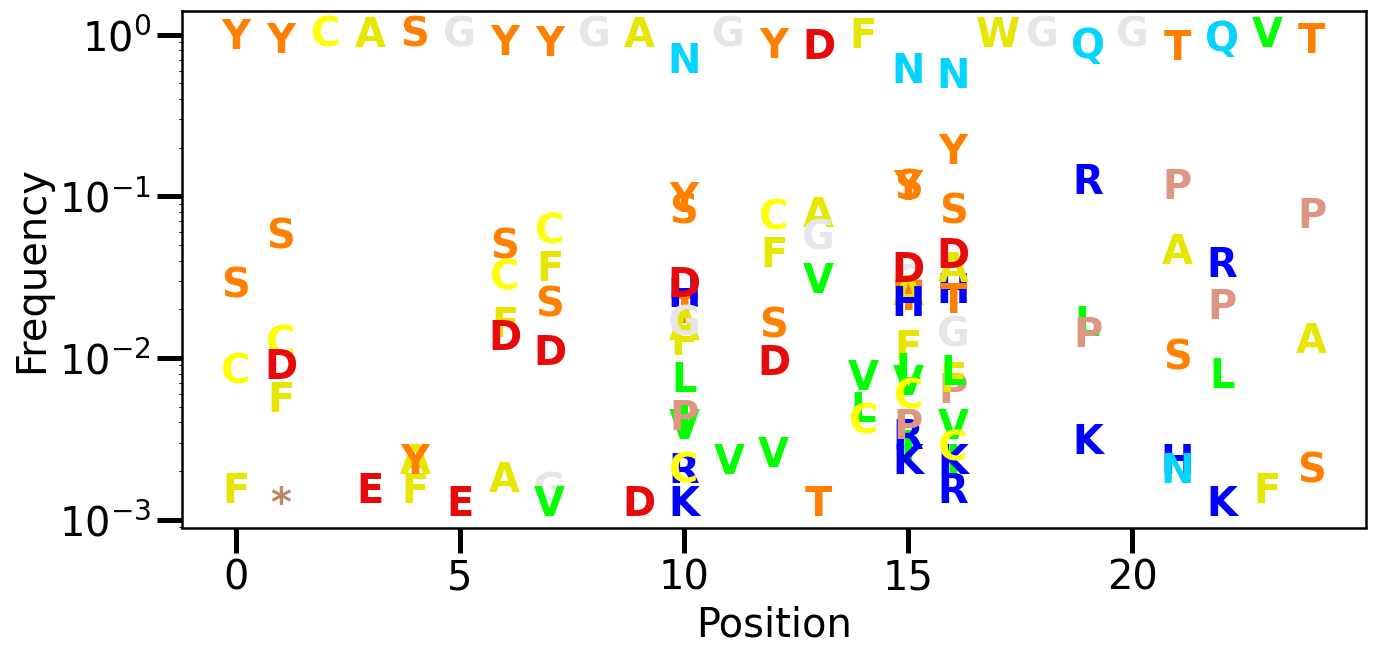

In [7]:
# Initialize a dictionary to hold frequency counts for each position
position_freqs = [defaultdict(int) for _ in range(len(prot_vr[0]))]

# Count frequencies for each position
for s in prot_vr:
    for i, char in enumerate(s):
        position_freqs[i][char] += 1

# Normalize frequencies
total_strings = len(prot_vr)
for i in range(len(position_freqs)):
    for char in position_freqs[i]:
        position_freqs[i][char] /= total_strings

# Create a single figure
plt.figure(figsize=(12, 6))

# For each position, plot letters with frequency > 1e-3
for pos in range(len(position_freqs)):
    freqs = position_freqs[pos]
    for char, freq in freqs.items():
        if freq > 1e-3:
            color = aa_colors.get(char, 'black')  # Default to black if not found
            plt.scatter(pos, freq, label=f'{char} at {pos}', alpha=0)
            plt.text(pos, freq, char, fontsize=24, ha='center', va='center', color=color, fontweight='bold')

# Customize the plot
plt.yscale('log')
plt.xlabel('Position',fontsize=24)
plt.ylabel('Frequency',fontsize=24)

#plt.grid(True, which="both", ls="--")
plt.xticks(list(range(0,len(position_freqs),5)),fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.savefig('TR_AA_freq_bis.svg')
plt.show()